In [1]:
from neo4j import GraphDatabase, Result, Record
import matplotlib.pyplot as plt
import networkx as nx
import json

In [2]:
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password-to-kg"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

In [3]:
try:
    driver.verify_connectivity()
            
except Exception as e:
    print(f"--- CONNECTION FAILED ---")
    print(f"Error: {e}")
    driver.close()
    raise RuntimeError("Neo4j connection could not be established. Please check your Docker container.")

In [4]:
cleanup_query = """
    CALL apoc.periodic.iterate(
    "MATCH (n) RETURN n",
    "DETACH DELETE n",
    {batchSize: 10000, parallel: false}
    )
    """

with driver.session() as session:
    session.run(cleanup_query)

    check_query = "MATCH (n) RETURN count(n) AS nodeCount"
    
    result = session.run(check_query)
    record = result.single()

    if record is None:
        print(f"⚠️ Warning: Querry result is None.")
    else:
        node_count = record['nodeCount']
        if record["nodeCount"] == 0:
            print("✅ Database is successfully cleared. Node count: 0")
        else:
            print(f"⚠️ Warning: Database still contains {node_count} nodes.")

✅ Database is successfully cleared. Node count: 0


In [5]:
with driver.session() as session:
    query = '''
        CREATE CONSTRAINT id_unique IF NOT EXISTS
        FOR (b:Base) REQUIRE b.id IS UNIQUE;
        '''
    session.run(query)

In [6]:
with open('./dataset/kb.json', encoding='utf-8') as f:
    dataset: dict = json.load(f)

print("Loading dataset from './dataset/kb.json'...")
with open('./dataset/kb.json', encoding='utf-8') as f:
    dataset: dict = json.load(f)
print("Dataset loaded successfully.")

Loading dataset from './dataset/kb.json'...
Dataset loaded successfully.


In [7]:
print("Preparing concept data for insertion...")
concepts: dict = dataset['concepts']
data = []
for (k,v) in concepts.items():
    data.append({'id': k, 'name': v['name']})
print(f"Prepared {len(data)} concepts for insertion.")

query = """
    UNWIND $batch as item
    MERGE (c:Concept:Base {id: item.id})
    SET c.name = item.name
    """

print("Inserting concepts into Neo4j database...")
with driver.session() as session:
    session.run(query, batch=data)
    
    print("Counting total nodes in database...")
    result: Result = session.run('MATCH (n) RETURN count(n) AS totalNodes')
    record = result.single()
    
    if record:
        count = record["totalNodes"]
        print(f"Total nodes in database: {count}")
    else:
        print("No nodes found in database.")

Preparing concept data for insertion...
Prepared 794 concepts for insertion.
Inserting concepts into Neo4j database...
Counting total nodes in database...
Total nodes in database: 794


In [8]:
data = []
for (k,v) in concepts.items():
    for parent_id in v['instanceOf']:
        data.append({'child_id': k, 'parent_id': parent_id})

query = """
    UNWIND $batch as item
    MATCH (child:Base {id: item.child_id})
    MATCH (parent:Base {id: item.parent_id})
    MERGE (child)-[:IS_A]->(parent)
    """

with driver.session() as session:
    session.run(query, batch=data)

    result: Result = session.run('MATCH ()-[r:IS_A]->() RETURN count(r) AS totalRelation')
    record = result.single()
    
    if record:
        count = record["totalRelation"]
        print(f"Total IS_A relationships in database: {count}")
    else:
        print("No IS_A relationships found in database.")

Total IS_A relationships in database: 365


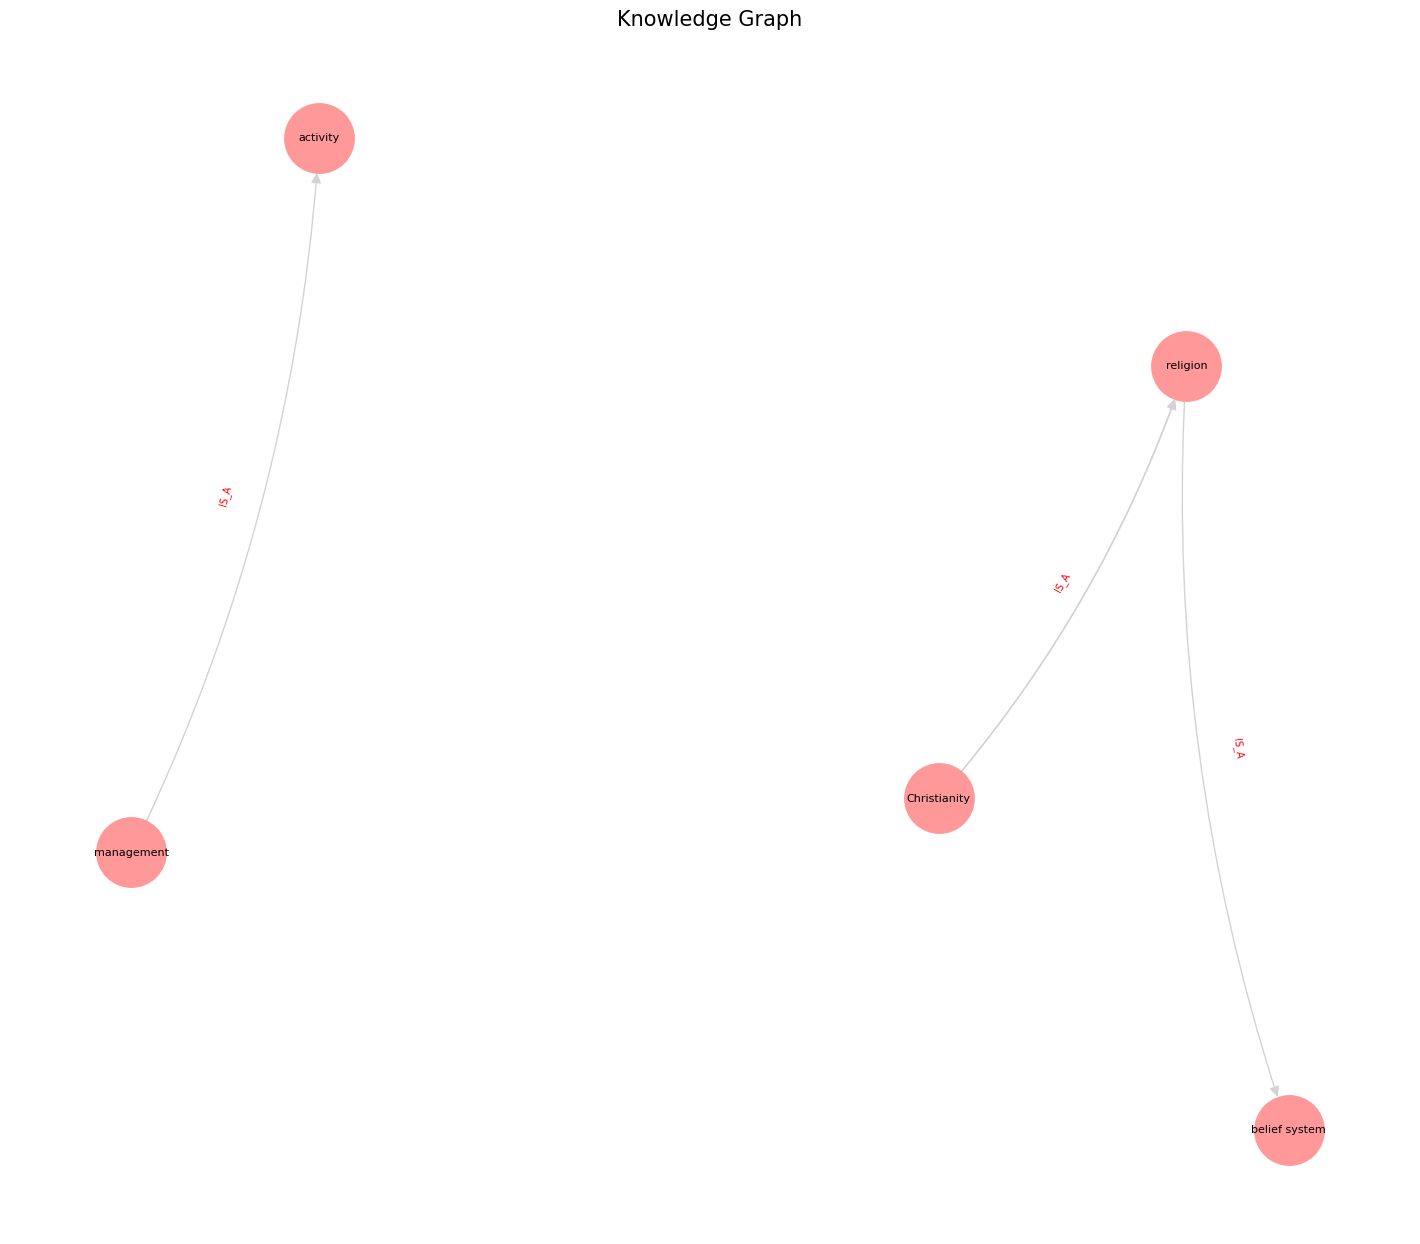

In [12]:
bfs_query = """
    MATCH (start:Base)
    WITH start, rand() AS r
    ORDER BY r
    LIMIT 5
    MATCH p = (start)-[*1..2]->(neighbor)
    RETURN p
"""

with driver.session() as session:
    result = session.run(bfs_query)
    
    G = nx.MultiDiGraph()
    
    for record in result:
        path = record['p']
        # Add nodes from the path
        for node in path.nodes:
            # Using .get("name", node.get("id", "Unknown")) to ensure we have a label
            node_label = node.get("name") if node.get("name") else node.get("id", "Unknown")
            G.add_node(node.element_id, label=node_label)
            
        # Add relationships from the path
        for rel in path.relationships:
            G.add_edge(
                rel.start_node.element_id, 
                rel.end_node.element_id, 
                type=rel.type,
            )

    # 2. Visualization
    plt.figure(figsize=(14, 12))
    
    node_labels = nx.get_node_attributes(G, 'label')
    # Increase k for more space between nodes in the BFS tree
    pos = nx.spring_layout(G, k=2.0, iterations=100)

    nx.draw(
        G, 
        pos, 
        labels=node_labels,
        with_labels=True, 
        node_color="#ff9999", # Different color for BFS view
        node_size=2500,
        font_size=8, 
        edge_color='#D3D3D3',
        arrowsize=15,
        connectionstyle='arc3, rad = 0.1'
    )

    edge_labels = nx.get_edge_attributes(G, 'type')

    nx.draw_networkx_edge_labels(
        G, 
        pos, 
        edge_labels=edge_labels, 
        font_color='red', 
        font_size=7,
        label_pos=0.5
    )

    plt.title("Knowledge Graph", fontsize=15)
    plt.show()

In [13]:
print("Preparing entity data for insertion...")
entities = dataset['entities']

data = []
for (k,v) in entities.items():
    data.append({'id': k, 'name': v['name'], 'attributes': str(v['attributes'])})
print(f"Prepared {len(data)} entities for insertion.")

query = """
    UNWIND $batch as item
    MERGE (e:Entity:Base {id: item.id})
    SET e.name = item.name, e.attributes = item.attributes
    """

print("Inserting entities into Neo4j database...")
with driver.session() as session:
    session.run(query, batch=data)
    
    print("Counting total nodes in database...")
    result: Result = session.run('MATCH (n) RETURN count(n) AS totalNodes')
    record = result.single()
    
    if record:
        count = record["totalNodes"]
        print(f"Total nodes in database: {count}")
    else:
        print("No nodes found in database.")

Preparing entity data for insertion...
Prepared 16960 entities for insertion.
Inserting entities into Neo4j database...
Counting total nodes in database...
Total nodes in database: 17754


In [14]:
data = []
for (k,v) in entities.items():
    for parent_id in v['instanceOf']:
        data.append({'child_id': k, 'parent_id': parent_id})

query = """
    UNWIND $batch as item
    MATCH (child:Base {id: item.child_id})
    MATCH (parent:Base {id: item.parent_id})
    MERGE (child)-[:IS_A]->(parent)
    """

with driver.session() as session:
    session.run(query, batch=data)

    result: Result = session.run('MATCH ()-[r:IS_A]->() RETURN count(r) AS totalRelation')
    record = result.single()
    
    if record:
        count = record["totalRelation"]
        print(f"Total IS_A relationships in database: {count}")
    else:
        print("No IS_A relationships found in database.")

Total IS_A relationships in database: 17325


In [15]:
# Use a dictionary to track unique (child, parent, name) combinations
unique_relations = {}

for k, v in entities.items():
    for relation in v['relations']:
        # 1. Determine direction and IDs
        name = relation['predicate']
        if relation['direction'] == 'forward':
            c_id, p_id = k, relation['object']
        else:
            c_id, p_id = relation['object'], k
        
        # 2. Create a unique key for this triple
        triple_key = (c_id, p_id, name)
        new_qualifier = str(relation['qualifiers'])

        # 3. Check if we've seen this triple before
        if triple_key in unique_relations:
            existing_item = unique_relations[triple_key]
            if new_qualifier not in existing_item['qualifiers']: # Avoid exact duplicate qualifiers
                existing_item['qualifiers'] += f" | {new_qualifier}"
        else:
            unique_relations[triple_key] = {
                'name': name,
                'child_id': c_id,
                'parent_id': p_id,
                'qualifiers': new_qualifier
            }

# Convert the dictionary values back into your final list
data = list(unique_relations.values())
print(len(data))

207851


In [16]:
query = """
    UNWIND $batch AS item
    MATCH (child:Base {id: item.child_id})
    MATCH (parent:Base {id: item.parent_id})
    CALL apoc.merge.relationship(
    child, 
    item.name, 
    {}, 
    {qualifiers: item.qualifiers}, 
    parent
    ) YIELD rel
    RETURN count(rel) AS total
    """

BATCH_SIZE = 10000
total_processed = 0

print(f"Processing {len(data)} relationships in batches of {BATCH_SIZE}...")

with driver.session() as session:
    for i in range(0, len(data), BATCH_SIZE):
        batch = data[i:i+BATCH_SIZE]
        print(f"Processing batch {i//BATCH_SIZE + 1}/{(len(data) + BATCH_SIZE - 1)//BATCH_SIZE} ({len(batch)} items)...")
        
        session.run(query, batch=batch)
        
        total_processed += len(batch)
        print(f"Progress: {total_processed}/{len(data)} relationships loaded")

    print("Counting total relationships in database...")
    result: Result = session.run('MATCH ()-[r]->() RETURN count(r) AS totalRelation')
    record = result.single()

    if record:
        count = record["totalRelation"]
        print(f"Total relationships in database: {count}")
    else:
        print("No relationships found in database.")

Processing 207851 relationships in batches of 10000...
Processing batch 1/21 (10000 items)...
Progress: 10000/207851 relationships loaded
Processing batch 2/21 (10000 items)...
Progress: 20000/207851 relationships loaded
Processing batch 3/21 (10000 items)...
Progress: 30000/207851 relationships loaded
Processing batch 4/21 (10000 items)...
Progress: 40000/207851 relationships loaded
Processing batch 5/21 (10000 items)...
Progress: 50000/207851 relationships loaded
Processing batch 6/21 (10000 items)...
Progress: 60000/207851 relationships loaded
Processing batch 7/21 (10000 items)...
Progress: 70000/207851 relationships loaded
Processing batch 8/21 (10000 items)...
Progress: 80000/207851 relationships loaded
Processing batch 9/21 (10000 items)...
Progress: 90000/207851 relationships loaded
Processing batch 10/21 (10000 items)...
Progress: 100000/207851 relationships loaded
Processing batch 11/21 (10000 items)...
Progress: 110000/207851 relationships loaded
Processing batch 12/21 (1000

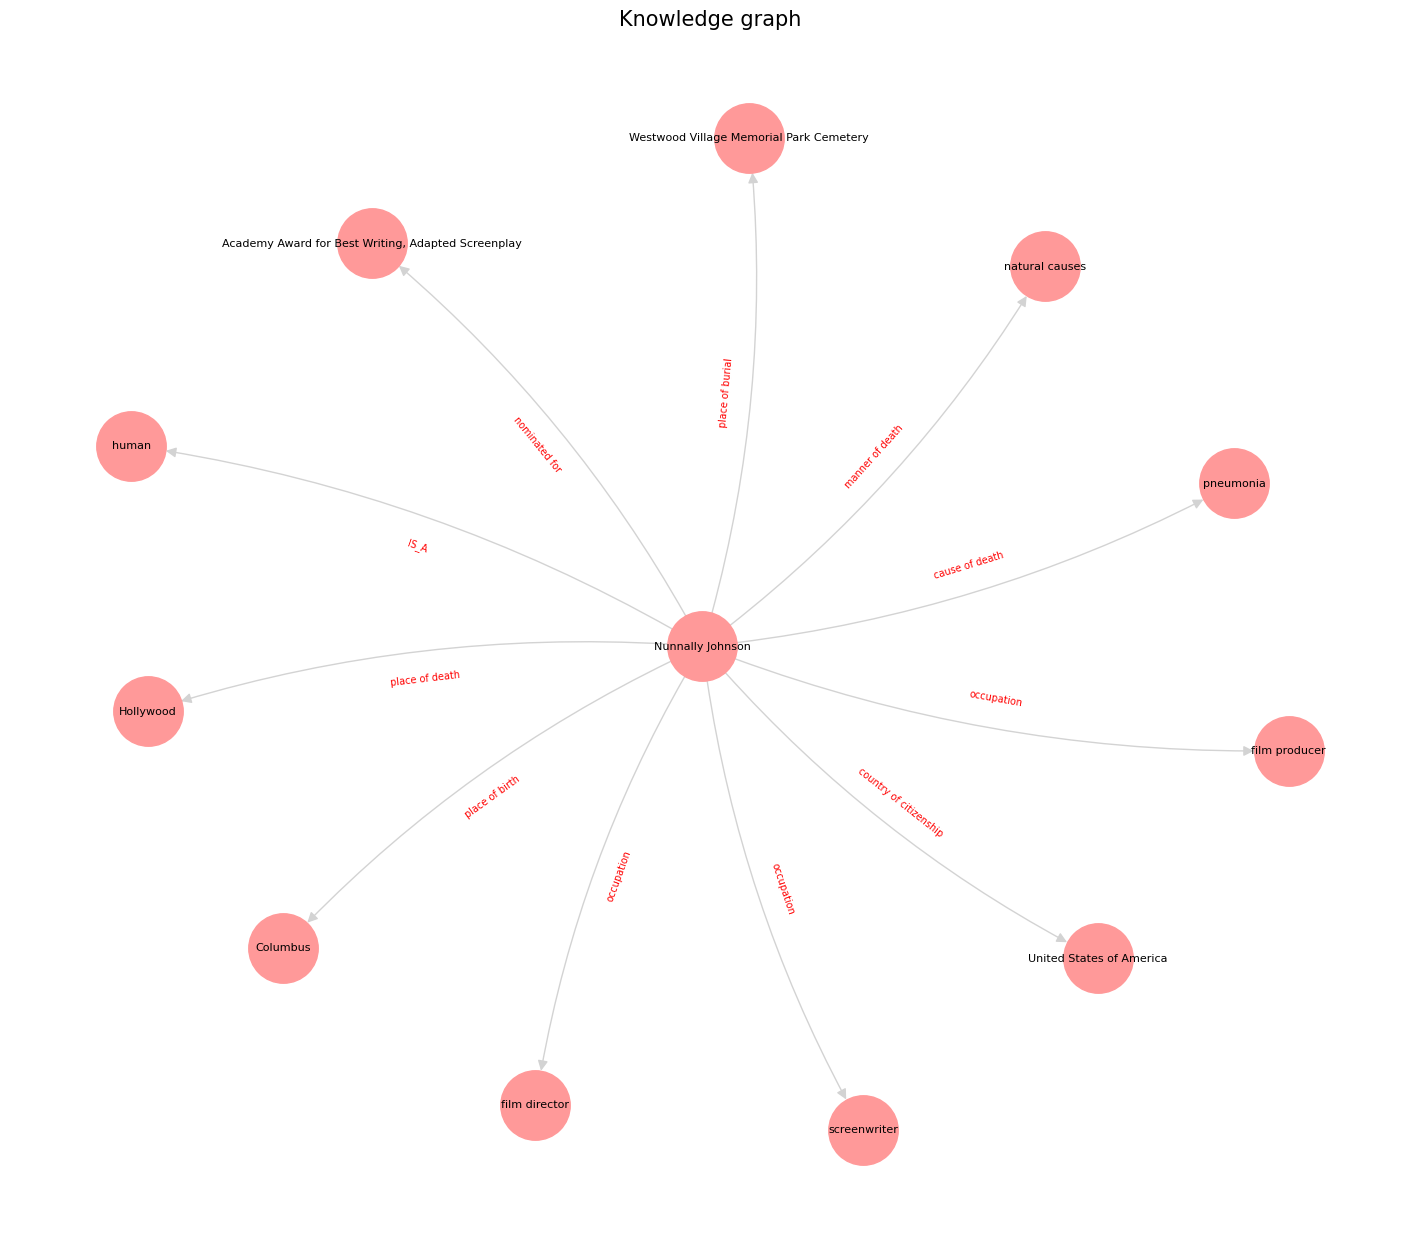

In [18]:
bfs_query = """
    MATCH (start:Base)
    WITH start, rand() AS r
    ORDER BY r
    LIMIT 1
    MATCH p = (start)-[]->(neighbor)
    RETURN p
"""

with driver.session() as session:
    result = session.run(bfs_query)
    
    G = nx.MultiDiGraph()
    
    for record in result:
        path = record['p']
        # Add nodes from the path
        for node in path.nodes:
            # Using .get("name", node.get("id", "Unknown")) to ensure we have a label
            node_label = node.get("name") if node.get("name") else node.get("id", "Unknown")
            G.add_node(node.element_id, label=node_label)
            
        # Add relationships from the path
        for rel in path.relationships:
            G.add_edge(
                rel.start_node.element_id, 
                rel.end_node.element_id, 
                type=rel.type
            )

    # 2. Visualization
    plt.figure(figsize=(14, 12))
    
    node_labels = nx.get_node_attributes(G, 'label')
    # Increase k for more space between nodes in the BFS tree
    pos = nx.spring_layout(G, k=2.0, iterations=100)

    nx.draw(
        G, 
        pos, 
        labels=node_labels,
        with_labels=True, 
        node_color="#ff9999", # Different color for BFS view
        node_size=2500,
        font_size=8, 
        edge_color='#D3D3D3',
        arrowsize=15,
        connectionstyle='arc3, rad = 0.1'
    )

    edge_labels = nx.get_edge_attributes(G, 'type')

    nx.draw_networkx_edge_labels(
        G, 
        pos, 
        edge_labels=edge_labels, 
        font_color='red', 
        font_size=7,
        label_pos=0.5
    )

    plt.title("Knowledge graph", fontsize=15)
    plt.show()

In [19]:
driver.close()